# Importing libraries

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim

import os
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Walkthrough the dataset

In [2]:
def walkthrough_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

image_path = Path("PetImages")
walkthrough_dir(image_path)

There are 2 directories and 0 images in 'PetImages'.
There are 0 directories and 12499 images in 'PetImages\Cat'.
There are 0 directories and 12499 images in 'PetImages\Dog'.


# Setup the device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("Using device", device)

Using device cuda


# Setup transforms for train/test

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Visualizing original and transformed images

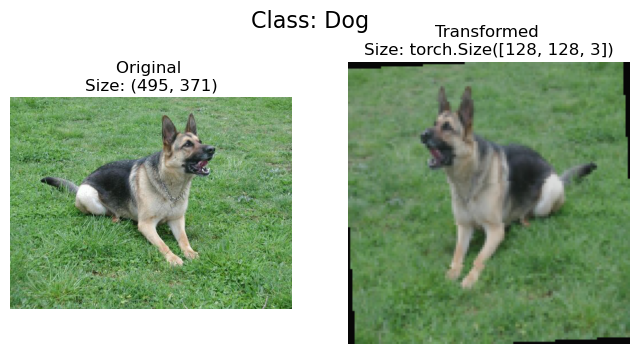

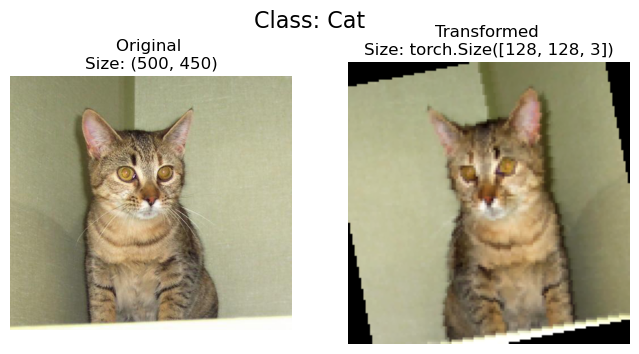

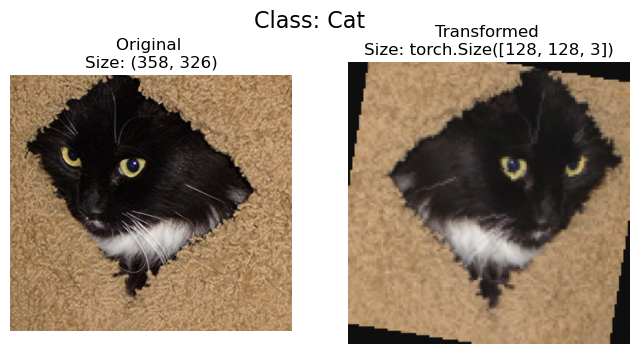

In [5]:
import random

def plot_transformed_images(image_paths, transform, n=3, seed=42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        try:
            with Image.open(image_path) as f:
                f = f.convert("RGB")
                fig, ax = plt.subplots(1, 2, figsize=(8, 4))
                ax[0].imshow(f)
                ax[0].set_title(f"Original \nSize: {f.size}")
                ax[0].axis("off")

                transformed_image = transform(f).permute(1, 2, 0)
                ax[1].imshow(transformed_image)
                ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
                ax[1].axis("off")

                fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
                plt.show()
        except Exception as e:
            print(f"Skipping {image_path}: {e}")

image_file_paths = list(Path("PetImages").rglob("*.jpg"))
plot_transformed_images(image_file_paths, train_transform, 3)

# Train/Test split

In [6]:
from torch.utils.data import random_split

full_dataset = datasets.ImageFolder(image_path)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

In [7]:
train_dataset.dataset.transform = train_transform
test_dataset.dataset.transform = test_transform

train_dataset = datasets.ImageFolder(image_path, transform=train_transform)
test_dataset  = datasets.ImageFolder(image_path, transform=test_transform)

# Data Loaders

In [8]:
num_workers = os.cpu_count()
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers
)

# Classes

In [9]:
classes = full_dataset.classes
print("Classes:", classes)

Classes: ['Cat', 'Dog']


In [10]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])


# Defining the CNN

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 32 -> 16

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 16 -> 8
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
model = CNN().to(device)
print(f"Model initialized {model}")

Model initialized CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.5, inplace=False)
    (5): Linea

# Trying a forward pass on a single image

In [13]:
img_single, label_single = images[0].unsqueeze(dim=0), labels[0]
print(f"Single image shape: {img_single.shape}\n")

# Perform a forward pass on a single image
model.eval()
with torch.inference_mode():
    pred = model(img_single.to(device))
    
# Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.sigmoid(pred)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.sigmoid(pred), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 128, 128])

Output logits:
tensor([[-0.0363]], device='cuda:0')

Output prediction probabilities:
tensor([[0.4909]], device='cuda:0')

Output prediction label:
tensor([0], device='cuda:0')

Actual label:
0


# Setting up optimizer and loss

In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Setting up the train and test functions

In [15]:
def train_step(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    acc = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        acc += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = acc / total

    return epoch_loss, epoch_acc

In [16]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    acc = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        acc += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = acc / total

    return epoch_loss, epoch_acc

# Training the model

In [17]:
num_epochs = 15
train_loss_results = []
train_acc_results = []
test_loss_results = []
test_acc_results = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_step(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    train_loss_results.append(train_loss)
    train_acc_results.append(train_acc)

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )
    test_loss_results.append(test_loss)
    test_acc_results.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Test Loss: {test_loss:.4f} "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch [1/15] Train Loss: 0.6847 Train Acc: 0.5502 Test Loss: 0.6677 Test Acc: 0.5758
Epoch [2/15] Train Loss: 0.6590 Train Acc: 0.5999 Test Loss: 0.6481 Test Acc: 0.6088
Epoch [3/15] Train Loss: 0.6220 Train Acc: 0.6543 Test Loss: 0.5853 Test Acc: 0.6879
Epoch [4/15] Train Loss: 0.5908 Train Acc: 0.6879 Test Loss: 0.5697 Test Acc: 0.6936
Epoch [5/15] Train Loss: 0.5611 Train Acc: 0.7134 Test Loss: 0.5135 Test Acc: 0.7520
Epoch [6/15] Train Loss: 0.5245 Train Acc: 0.7424 Test Loss: 0.4959 Test Acc: 0.7725
Epoch [7/15] Train Loss: 0.4820 Train Acc: 0.7727 Test Loss: 0.4221 Test Acc: 0.8085
Epoch [8/15] Train Loss: 0.4511 Train Acc: 0.7935 Test Loss: 0.4688 Test Acc: 0.7797
Epoch [9/15] Train Loss: 0.4240 Train Acc: 0.8090 Test Loss: 0.3828 Test Acc: 0.8312
Epoch [10/15] Train Loss: 0.3956 Train Acc: 0.8236 Test Loss: 0.4703 Test Acc: 0.7859
Epoch [11/15] Train Loss: 0.3745 Train Acc: 0.8357 Test Loss: 0.3506 Test Acc: 0.8439
Epoch [12/15] Train Loss: 0.3517 Train Acc: 0.8469 Test Loss: 0

# Visualizing the train/test accuracy and loss

C:\Users\onest\AppData\Local\Temp\ipykernel_22336\3368232957.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


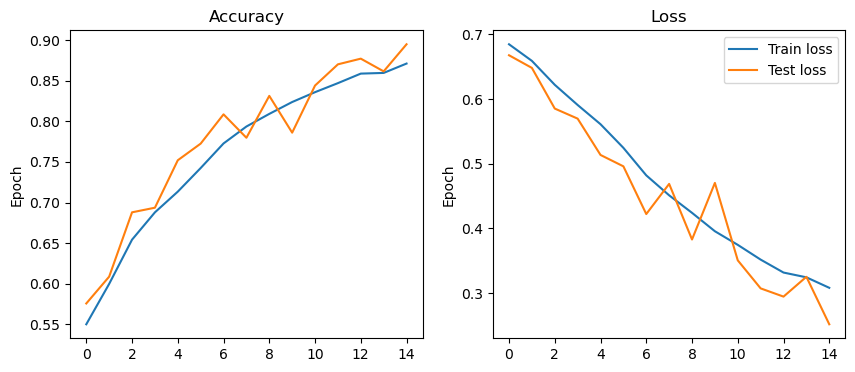

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
epoch_range = torch.arange(num_epochs)
# train_acc_results = torch.rand(15)
# test_acc_results = torch.rand(15)
# train_loss_results = torch.rand(15)
# test_loss_results = torch.rand(15)

axs[0].plot(epoch_range, train_acc_results, label = "Train accuray")
axs[0].plot(epoch_range, test_acc_results,  label = "Test accuray")
axs[0].set_title("Accuracy")
axs[0].set_ylabel("Epoch")

axs[1].plot(epoch_range, train_loss_results, label = "Train loss")
axs[1].plot(epoch_range, test_loss_results, label = "Test loss")
axs[1].set_title("Loss")
axs[1].set_ylabel("Epoch")

plt.legend()
plt.show()

# Testing the model with a random image

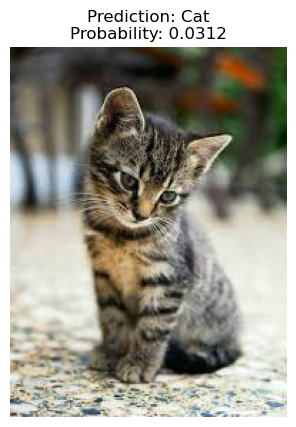

In [19]:
custom_image_path = Path("test.jpg")
img = Image.open(custom_image_path).convert("RGB")
x = test_transform(img).unsqueeze(0).to(device)

model.eval()
with torch.inference_mode():
    logits = model(x)
    prob = torch.sigmoid(logits).item()

pred_class = classes[1] if prob > 0.5 else classes[0]

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {pred_class}\n"
    f"Probability: {prob:.4f}"
)
plt.show()


# Confusion matrix heatmap

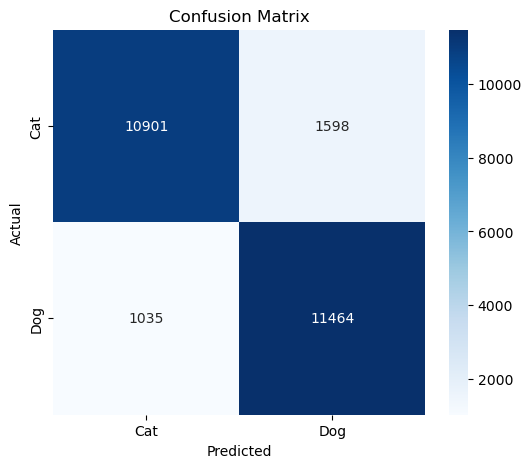

In [20]:
@torch.no_grad()
def plot_confusion_matrix(model, loader, classes, device):
    model.eval()

    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device)

        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy().flatten()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes,
        cmap='Blues'
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(
    model,
    test_loader,
    classes,
    device
)

# Saving the model

In [21]:
torch.save(model.state_dict(), "cat_dog_cnn.pth")

In [22]:
loadmodel = CNN()
loadmodel.load_state_dict(torch.load('cat_dog_cnn.pth', weights_only=True))
loadmodel.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=128,